In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
visadata_df = pd.read_csv("Visadataset.csv")

In [9]:
cat = visadata_df.select_dtypes(include="object").columns
num = visadata_df.select_dtypes(exclude="object").columns




# we have 2 types of scaling

- z scoring (standardization)
- min max scalar (normalization)

In [4]:
step -1 : read , pwage column  x

SyntaxError: illegal target for annotation (133967311.py, line 1)

In [10]:
visadata_df['prevailing_wage'].describe()

count     25480.000000
mean      74455.814592
std       52815.942327
min           2.136700
25%       34015.480000
50%       70308.210000
75%      107735.512500
max      319210.270000
Name: prevailing_wage, dtype: float64

In [13]:
x = visadata_df['prevailing_wage']
u = np.mean(visadata_df['prevailing_wage'])
std = np.std(visadata_df['prevailing_wage'])
a = x - u
b  = a/std


3.274401278775317
3.6895997843396002
3.1096430565993405
3.0461872964673673
3.442323001807008
3.5545492739042546
3.333431205025178
3.441255121460693
3.014033684316507
3.7785472115896166
3.2613744639336835
3.1394645619726194
3.410936029287748
4.04929426220173
3.218819810814008
3.1750632242832673
3.277283419667446
3.023452426839102
3.1301355668408317
3.0878310325043974
3.635047192584297
3.84030212612745
3.808996191336599
3.310340185940987
4.12101037975723
3.021046666612102
3.2671349589082017
3.659388805584696
3.9043014827974143
3.8536224187238335
3.567115991362636
3.586513924249154
3.6032408308864765
3.6620863395020624
3.179983047495793
3.8329759746664642
3.9264884010564893
3.4807791907464827
3.237019029077739
3.3292356091751794
3.727903554187092
3.3772529246834244
3.3932285282685877
3.2446021155794966
3.1242976316071562
3.0646754483141616
4.384484672925674
3.717589041820806
3.454477146344357
3.187684471801885
3.3826669265668516
3.6729122605235607
3.00473119685289
4.410766268555211
3.2905

(array([6038., 5504., 5681., 4551., 2334.,  624.,  373.,  240.,  114.,
          21.]),
 array([-1.40970956, -0.80531933, -0.20092909,  0.40346114,  1.00785137,
         1.61224161,  2.21663184,  2.82102207,  3.42541231,  4.02980254,
         4.63419278]),
 <BarContainer object of 10 artists>)

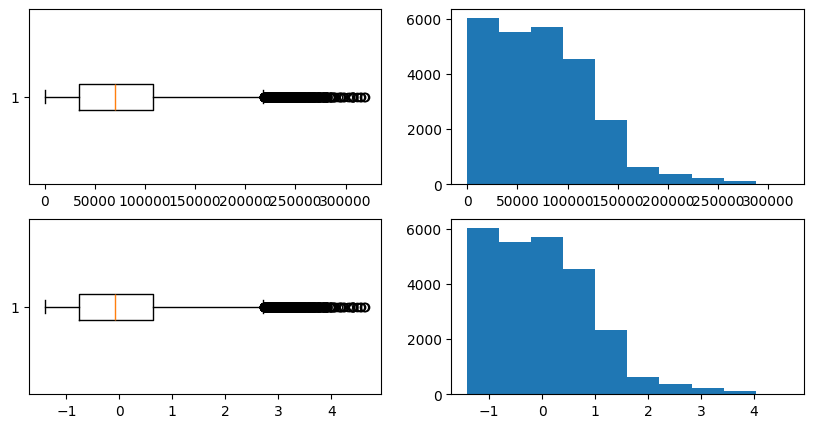

In [15]:
plt.figure(figsize=(10,5))
plt.subplot(2,2,1).boxplot(visadata_df['prevailing_wage'],vert=False)
plt.subplot(2,2,2).hist(visadata_df['prevailing_wage'])
plt.subplot(2,2,3).boxplot(visadata_df['p_z'],vert=False)
plt.subplot(2,2,4).hist(visadata_df['p_z'])

# method  StandardScaler
# from sklearn.preprocessing import StandardScaler

In [19]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
visadata_df['prevailing_wage_ss'] = ss.fit_transform(visadata_df[['prevailing_wage']])


In [20]:
visadata_df[['prevailing_wage',"p_z","prevailing_wage_ss"]]

,prevailing_wage,p_z,prevailing_wage_ss
0,592.2029,-1.398537,-1.398537
1,83425.6500,0.169835,0.169835
2,122996.8600,0.919079,0.919079
3,83434.0300,0.169994,0.169994
4,149907.3900,1.428604,1.428604
...,...,...,...
25475,77092.5700,0.049924,0.049924
25476,279174.7900,3.876159,3.876159
25477,146298.8500,1.360280,1.360280
25478,86154.7700,0.221509,0.221509


# Normalization

In [21]:
visadata_df = pd.read_csv("Visadataset.csv")

In [22]:
visadata_df['prevailing_wage'].describe()

count     25480.000000
mean      74455.814592
std       52815.942327
min           2.136700
25%       34015.480000
50%       70308.210000
75%      107735.512500
max      319210.270000
Name: prevailing_wage, dtype: float64

In [23]:
x = visadata_df['prevailing_wage']
x_min = np.min(visadata_df['prevailing_wage'])
x_max = np.max(visadata_df['prevailing_wage'])

visadata_df["x_new"] = (x - x_min) / (x_max - x_min)

In [24]:
visadata_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,x_new
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,0.001849
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,0.261345
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,0.385312
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,0.261371
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,0.469616
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified,0.241505
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified,0.874579
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified,0.458311
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified,0.269895


In [28]:
from sklearn.preprocessing import MinMaxScaler
MM = MinMaxScaler()
visadata_df["min_max"] =  MM.fit_transform(visadata_df[['prevailing_wage']])

In [29]:
visadata_df[["min_max","x_new"]]

,min_max,x_new
0,0.001849,0.001849
1,0.261345,0.261345
2,0.385312,0.385312
3,0.261371,0.261371
4,0.469616,0.469616
...,...,...
25475,0.241505,0.241505
25476,0.874579,0.874579
25477,0.458311,0.458311
25478,0.269895,0.269895


# KNN Immputer (k -nearest neighbour)

- K - Nearest nroghbours

- where k = hyper parameter which means the user can change

- idea - instead of taking all the samples average

- first fix the neighbours number i.e k

- then find the neighbour using distance metric

- then take the average if those samples to fill the missing value


In [2]:
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer

In [4]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
x= [[1,2,np.nan] , [3,np.nan, 3] , [np.nan , 60,5] , [8,8,7]]
pd.DataFrame(data= x)

,0,1,2
0,1.0,2.0,NaN
1,3.0,NaN,3.0
2,NaN,60.0,5.0
3,8.0,8.0,7.0


In [ ]:
 import method (from sklearn.preprocessing import KNNImputer)
 save method
 fit_transform

In [9]:
from sklearn.impute import KNNImputer
x= [[1,2,np.nan] , [3,np.nan, 3] , [np.nan , 60,5] , [8,8,7]]
knn = KNNImputer(n_neighbors= 2, weights= "uniform") # uniform means equal () different (2*x2 + 3*x1) it means
knn.fit_transform(x)

array([[ 1. ,  2. ,  5. ],
       [ 3. , 31. ,  3. ],
       [ 5.5, 60. ,  5. ],
       [ 8. ,  8. ,  7. ]])